# Interpretando os Resultados do Modelo

- Um dos grandes benefícios de se usar as representações de Bag of Words e TF-IDF é que elas são fáceis de interpretar.

In [7]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt
from movie_review_dataset import MovieReviewDataset

In [10]:
dataset = MovieReviewDataset()
train_df = dataset.get_train_data()
test_df = dataset.get_test_data()

In [11]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    37 non-null     object
 1   target  37 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 720.0+ bytes


In [12]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10 non-null     object
 1   target  10 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 288.0+ bytes


In [13]:
bow = CountVectorizer(min_df=0.01, lowercase=True, stop_words='english')
tfidf = TfidfTransformer()
model = LogisticRegression()

X_train = bow.fit_transform(train_df['text'])
X_test = bow.transform(test_df['text'])
X_train = tfidf.fit_transform(X_train)
X_test = tfidf.transform(X_test)

y_train = train_df['target']
y_test = test_df['target']

model = model.fit(X_train, y_train)

## Regressão Logística
- Para a Regressão Logística, podemos calcular os coeficientes de cada palavra e ver como elas afetam a probabilidade de uma sentença ser positiva ou negativa.

In [14]:
coefficients = model.coef_
words = bow.get_feature_names_out()

coefficients_df = pd.DataFrame({'words': words, 'coefficients': coefficients[0]})
coefficients_df = coefficients_df.sort_values(by='coefficients', ascending=False)

In [15]:
model.classes_

array([0, 1])

In [16]:
coefficients_df.head(10)

,words,coefficients
62,loved,0.446176
56,kept,0.345462
9,brilliant,0.332272
52,highly,0.332001
82,recommend,0.332001
24,direction,0.297907
0,10,0.290626
29,effects,0.288939
112,visual,0.288939
81,really,0.247912


In [17]:
coefficients_df.tail(10)

,words,coefficients
110,unrealistic,-0.263286
15,cheesy,-0.263286
91,slow,-0.320989
33,enjoy,-0.347452
45,flat,-0.358791
78,potential,-0.358791
25,disappointing,-0.399710
43,felt,-0.444645
22,didn,-0.465635
42,fell,-0.495992


In [18]:
model.predict(tfidf.transform(bow.transform(['This movie is disappointing'])))

array([0])

## E para Modelos mais Complexos?

### Random Forest

In [19]:
model = RandomForestClassifier()
model = model.fit(X_train, y_train)

In [20]:
feature_importance = model.feature_importances_
words = bow.get_feature_names_out()

feature_importance_df = pd.DataFrame({'words': words, 'feature_importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='feature_importance', ascending=False)

feature_importance_df.head(10)

,words,feature_importance
42,fell,0.032870
43,felt,0.029833
14,characters,0.029412
62,loved,0.027958
22,didn,0.027266
56,kept,0.021498
78,potential,0.020548
91,slow,0.019374
15,cheesy,0.019321
25,disappointing,0.018685


## Permutation Analysis
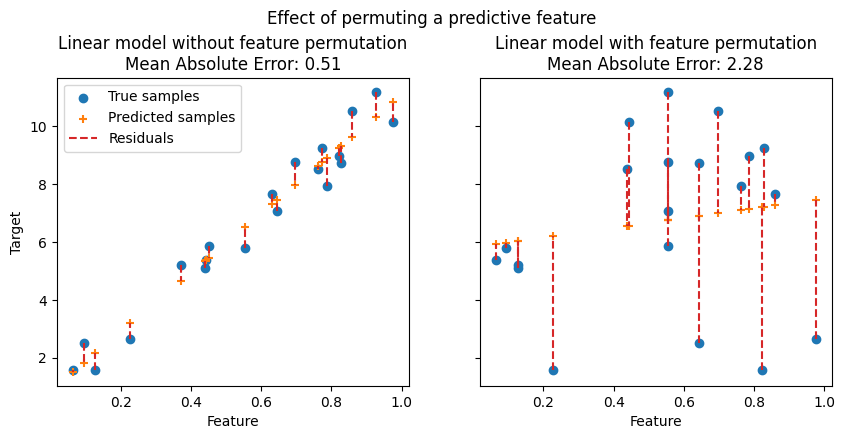

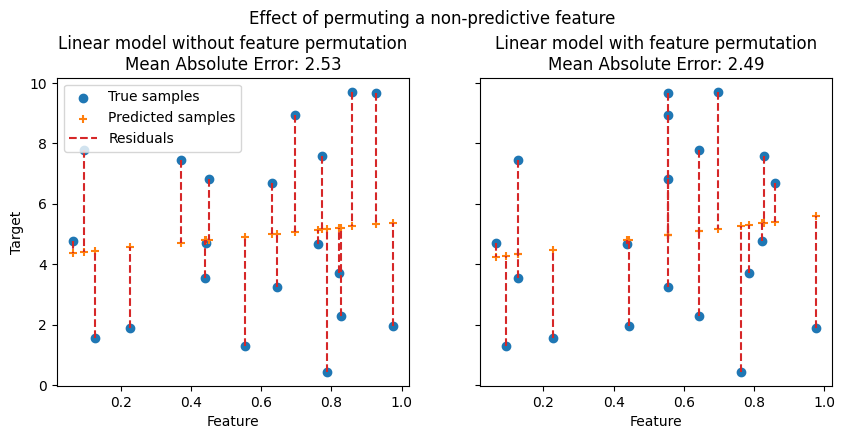

In [21]:
from sklearn.inspection import permutation_importance

In [22]:
result = permutation_importance(
    model, X_test.toarray(), y_test, n_repeats=10, random_state=42, n_jobs=2
)

In [23]:
forest_importances = pd.Series(result.importances_mean, index=bow.get_feature_names_out())

In [24]:
forest_importances.sort_values(ascending=False).head(10)

slow           0.09
plot           0.09
poorly         0.08
couldn         0.07
movie          0.03
ve             0.03
loved          0.02
masterpiece    0.02
performance    0.01
matched        0.00
dtype: float64

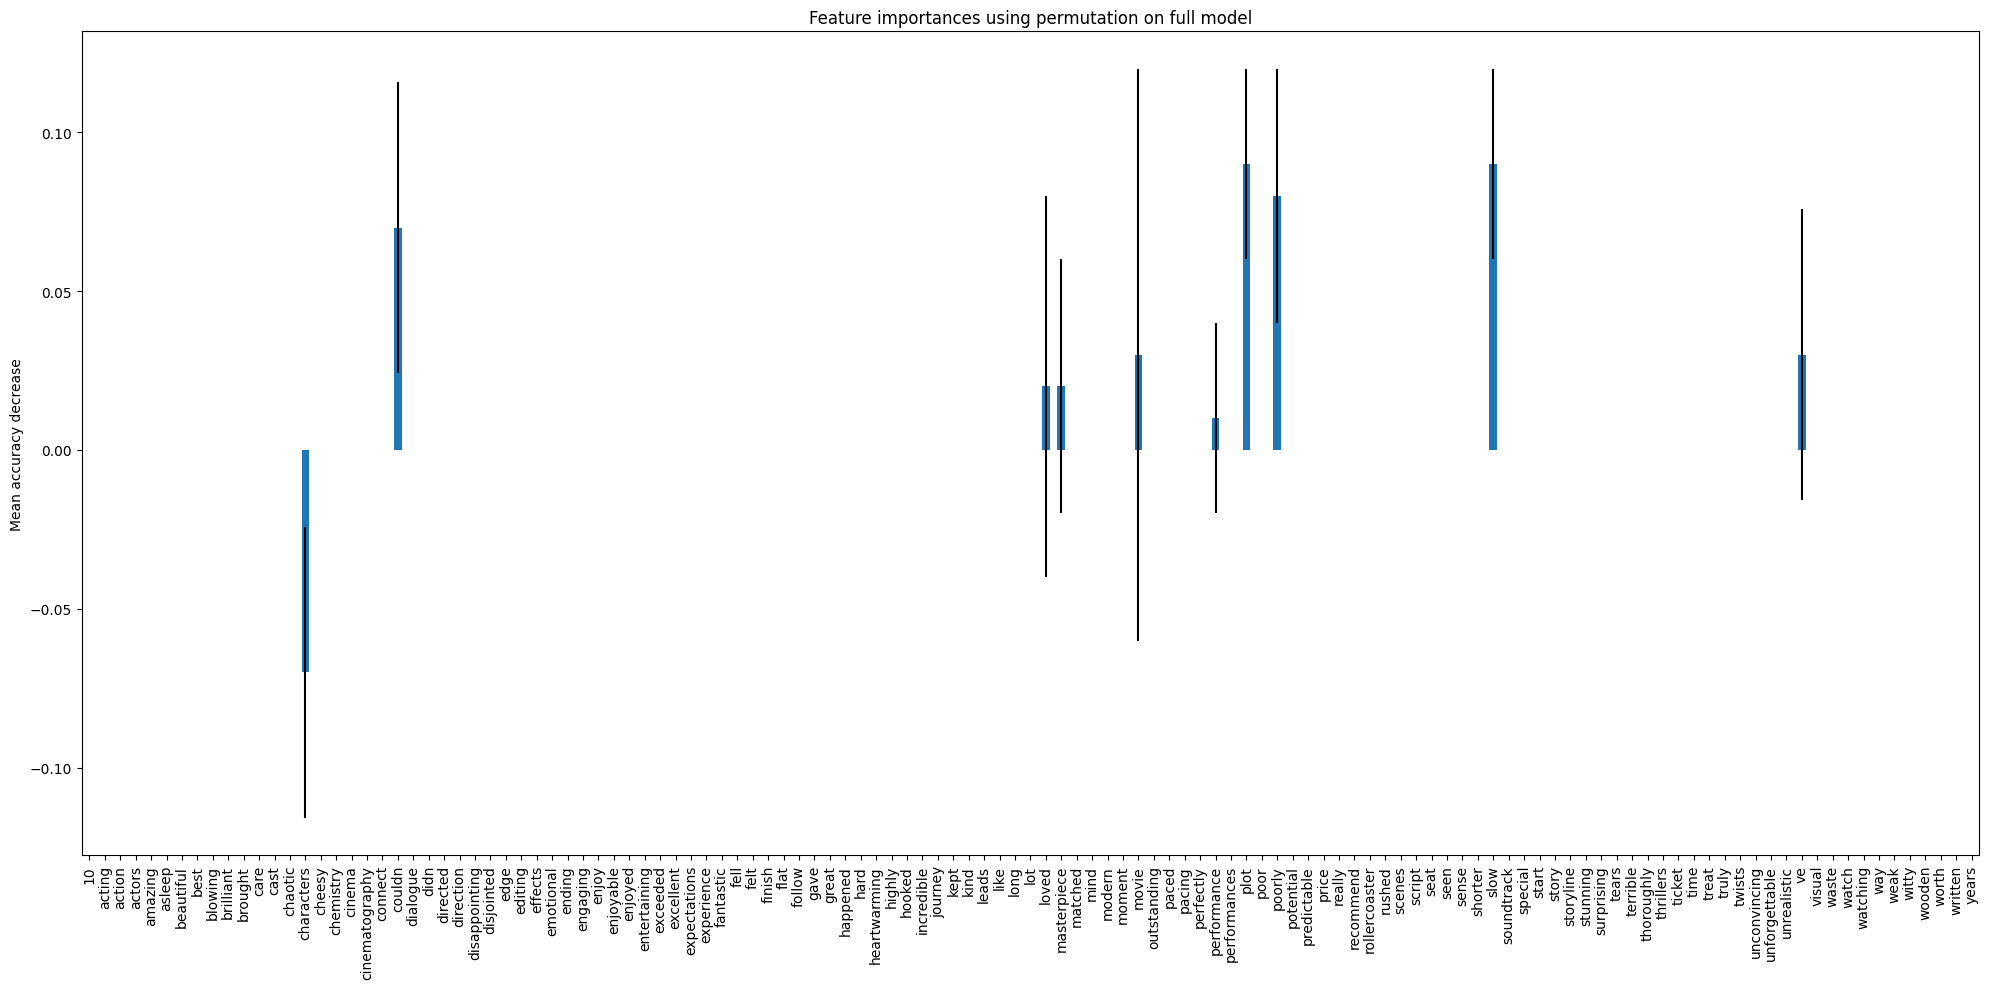

In [25]:
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=result.importances_std, ax=ax)
fig.set_size_inches(20, 10)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

## Shap Values
- Uma outra maneira de interpretar os resultados de modelos de Machine Learning é usando SHAP Values.
- Podemos compreender não apenas a importância de uma feature mas como ela afeta a predição de um modelo.

In [27]:
%pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 538.6/538.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 14.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 MB 26.4 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [28]:
import shap
shap.initjs()

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test.toarray())

In [29]:
explainer.expected_value

array([0.48891892, 0.51108108])

In [31]:
class_index = 1

idx = 1
print(test_df['text'].iloc[idx])
shap.plots.force(explainer.expected_value[class_index], shap_values[class_index][idx], X_test.toarray()[idx], feature_names=bow.get_feature_names_out())

I couldn't get into the story, too dull for me


### MLP

In [32]:
model = MLPClassifier()
model = model.fit(X_train, y_train)

Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.


In [33]:
explainer = shap.KernelExplainer(model.predict_proba, X_test.toarray())
shap_values = explainer.shap_values(X_test.toarray())

100%|██████████████████████████████████████████████████████████████████████████████████████| 10/10 [00:01<00:00,  6.07it/s]


In [35]:
class_index = 1

idx = 1
print(test_df['text'].iloc[idx])
shap.plots.force(explainer.expected_value[class_index], shap_values[class_index][idx], X_test.toarray()[idx], feature_names=bow.get_feature_names_out())

I couldn't get into the story, too dull for me


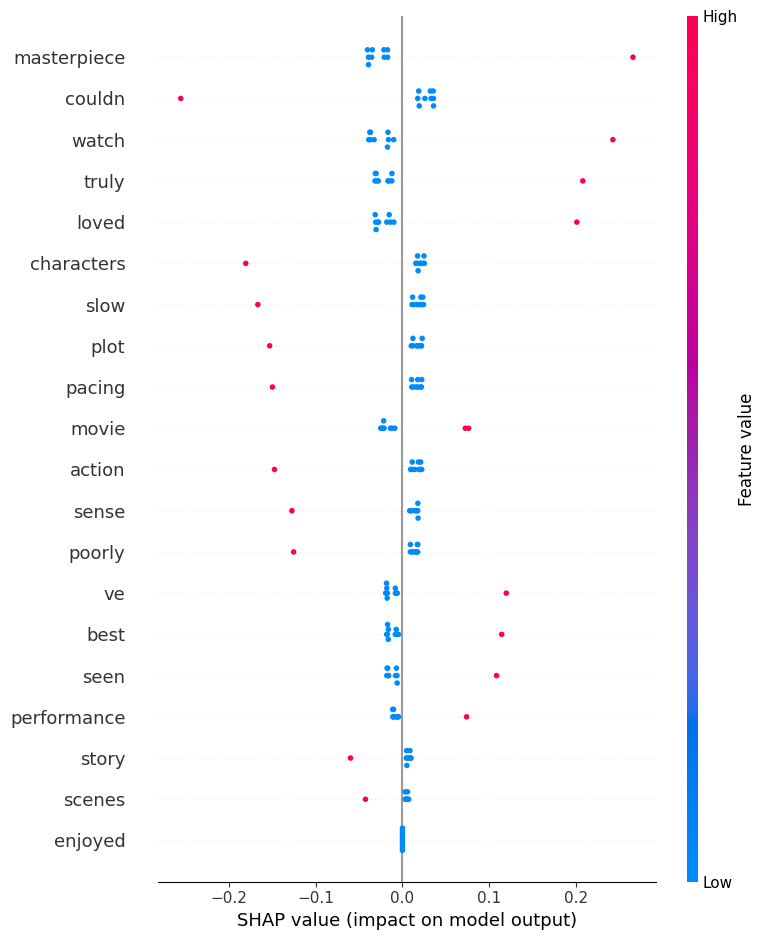

In [37]:
# Summary plot to visualize the global impact of features
shap.summary_plot(shap_values[class_index], X_test.toarray(), feature_names=bow.get_feature_names_out())